In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def logistic_function(x, L, k, x0):
    """
    Logistic (sigmoid) function
    
    Parameters:
    x : array-like - input values
    L : float - carrying capacity (maximum value)
    k : float - growth rate (steepness)
    x0 : float - x-value of the midpoint
    """
    return L / (1 + np.exp(-k * (x - x0)))

/var/folders/qn/rcpbyl8d6rs2ym4z26w2fk7wyq1ksg/T/ipykernel_67380/1398056545.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


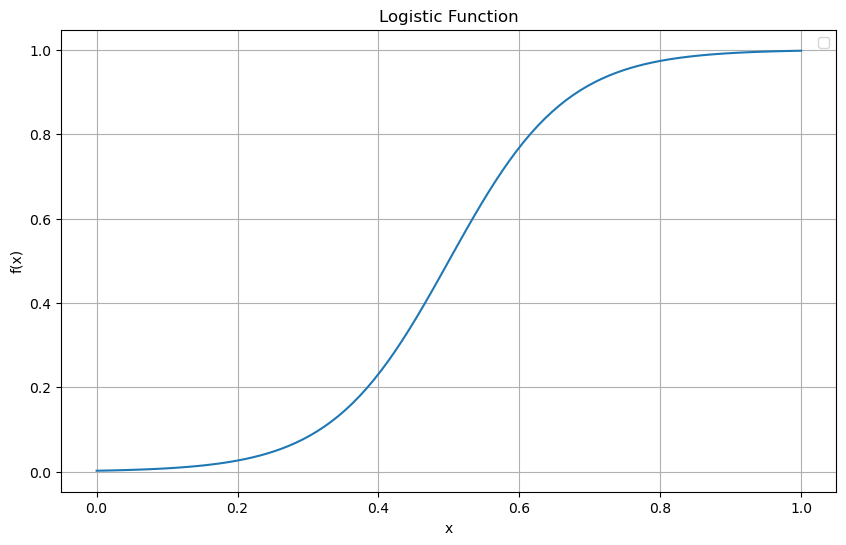

In [3]:
# Generate x values from -10 to 10 (adjust as needed)
x = np.linspace(0, 1, 100)

# Parameters to demonstrate different curves
L = 1
k = 12
x0 = 0.5
# Create the plot
plt.figure(figsize=(10, 6))

# Plot for each parameter set
y = logistic_function(x, L, k, x0)
plt.plot(x, y)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Logistic Function')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [4]:
def logistic_adapted_to_SN(x, midpoint, k=15):
    """Logistic curve scaled to [0,1] with adjustable midpoint."""
    # Shift and scale to enforce f(0)=0, f(1)=1, f(midpoint)=0.5
    x_scaled = (x - midpoint) * k  # Center at midpoint, scale by steepness
    sigmoid = 1 / (1 + np.exp(-x_scaled))  # Standard sigmoid
    # Linear transformation to map sigmoid's range (0,1) to [0,1]
    return sigmoid

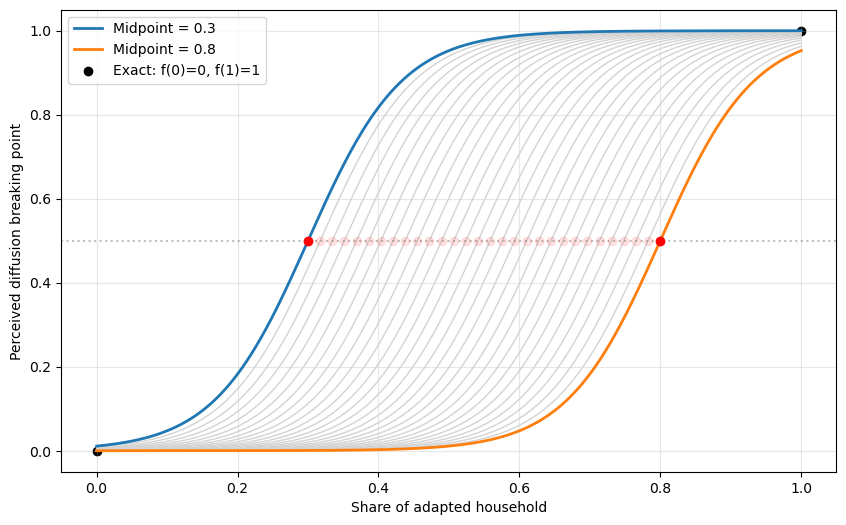

In [5]:
# Generate x values
x = np.linspace(0, 1, 500)

# Parameters
midpoint_start = 0.3
midpoint_end = 0.8
k = 15  # Steepness

# Generate 30 evenly spaced midpoints between 0.3 and 0.8
midpoints = np.linspace(midpoint_start, midpoint_end, 30)

plt.figure(figsize=(10, 6))

# Plot all 10 curves in light grey
for x0 in midpoints:
    y = logistic_adapted_to_SN(x, midpoint=x0, k=k)
    plt.plot(x, y, color='lightgrey', linewidth=1)

# Highlight the curves for midpoint = 0.3 and 0.8
for x0 in [midpoint_start, midpoint_end]:
    y = logistic_adapted_to_SN(x, midpoint=x0, k=k)
    plt.plot(x, y, label=f'Midpoint = {x0}', linewidth=2)

# Highlight key points
for x0 in [midpoint_start, midpoint_end]:
    plt.scatter(x0, 0.5, color='red', zorder=5)  # Midpoint markers

for x0 in midpoints:
    plt.scatter(x0, 0.5, color='red', zorder=5, alpha=0.1)  # Midpoint markers

plt.scatter([0, 1], [0, 1], color='black', label='Exact: f(0)=0, f(1)=1')
plt.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel("Share of adapted household")
plt.ylabel("Perceived diffusion breaking point")
plt.savefig('../../reports/figures/SN_curve_midpoint_plot.png')
plt.show()